BLOC 0 — Imports et configuration

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

BASE    = Path(r"C:\Users\NIAMBELE Siata\Desktop\MSPR2")
DB_PATH = BASE / "03_database" / "mspr2.db"

OUT_ETL       = BASE / "04_outputs" / "etl"
OUT_EDA       = BASE / "04_outputs" / "eda"
OUT_ELECTORAL = BASE / "04_outputs" / "electoral"

for d in [OUT_ETL, OUT_EDA, OUT_ELECTORAL]:
    d.mkdir(parents=True, exist_ok=True)

PALETTE_FAMILLES = {
    "Extreme gauche"      : "#8B0000",
    "Gauche radicale"     : "#CC0000",
    "Gauche"              : "#E87070",
    "Ecologie"            : "#2E8B57",
    "Centre"              : "#FFD700",
    "Droite"              : "#4169E1",
    "Droite souverainiste": "#1C3B8A",
    "Extreme droite"      : "#0A0A2A",
    "Divers"              : "#999999",
    "Inconnu"             : "#CCCCCC",
}
FAMILLES_ORDER = list(PALETTE_FAMILLES.keys())

REGROUP = {
    "Extreme gauche"      : "Gauche",
    "Gauche radicale"     : "Gauche",
    "Gauche"              : "Gauche",
    "Ecologie"            : "Gauche",
    "Centre"              : "Centre",
    "Droite"              : "Droite",
    "Droite souverainiste": "Droite",
    "Extreme droite"      : "Extreme droite",
    "Divers"              : "Divers",
    "Inconnu"             : "Divers",
}
COULEURS_REGROUP = {
    "Centre"        : "#DDAA00",
    "Droite"        : "#4488CC",
    "Extreme droite": "#1A1A6E",
    "Gauche"        : "#FF6666",
    "Divers"        : "#AAAAAA",
}

def load(query):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql(query, conn)

print("Configuration OK")
print(f"DB : {DB_PATH}")

Configuration OK
DB : C:\Users\NIAMBELE Siata\Desktop\MSPR2\03_database\mspr2.db


## VISUALISATIONS ETL

BLOC 1 — ETL : Volumétrie brute → staging → base

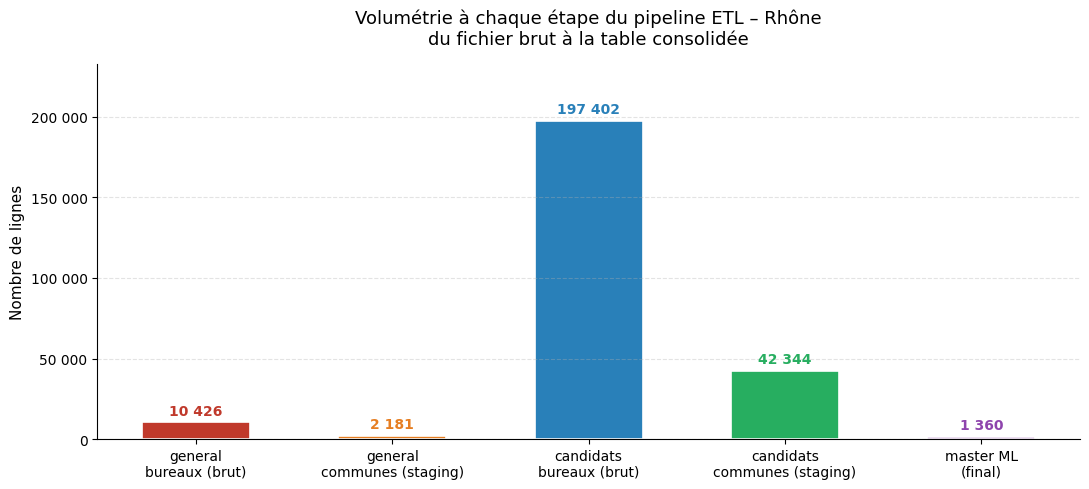

In [2]:
volumes = {
    "general\nbureaux (brut)"      : load("SELECT COUNT(*) n FROM general_bureaux").iloc[0,0],
    "general\ncommunes (staging)"  : load("SELECT COUNT(*) n FROM general_communes").iloc[0,0],
    "candidats\nbureaux (brut)"    : load("SELECT COUNT(*) n FROM candidats_bureaux").iloc[0,0],
    "candidats\ncommunes (staging)": load("SELECT COUNT(*) n FROM candidats_communes").iloc[0,0],
    "master ML\n(final)"           : load("SELECT COUNT(*) n FROM master_ml").iloc[0,0],
}

labels = list(volumes.keys())
vals   = list(volumes.values())
colors = ["#c0392b","#e67e22","#2980b9","#27ae60","#8e44ad"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, vals, color=colors, width=0.55, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(vals) * 0.015,
        f"{val:,}".replace(",", " "),
        ha="center", va="bottom", fontsize=10, fontweight="bold",
        color=bar.get_facecolor()
    )
ax.set_ylabel("Nombre de lignes", fontsize=11)
ax.set_title("Volumétrie à chaque étape du pipeline ETL – Rhône\ndu fichier brut à la table consolidée",
             fontsize=13, pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))
ax.set_ylim(0, max(vals) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(OUT_ETL / "etl1_volumetrie.png", dpi=150)
plt.show()

BLOC 2 — ETL : Couverture du mapping des nuances politiques

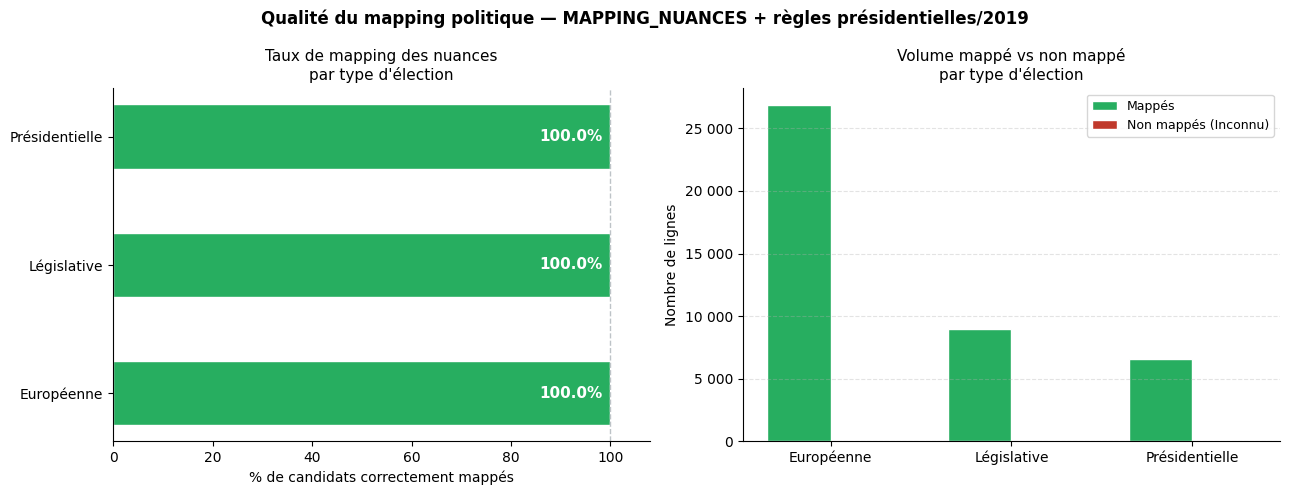

In [3]:
df_map = load("""
    SELECT type_election,
           SUM(CASE WHEN famille_politique != 'Inconnu' THEN 1 ELSE 0 END) AS mapped,
           SUM(CASE WHEN famille_politique  = 'Inconnu' THEN 1 ELSE 0 END) AS non_mapped,
           COUNT(*) AS total
    FROM candidats_communes
    GROUP BY type_election
""")
df_map["taux_mapping"] = df_map["mapped"] / df_map["total"] * 100
df_map = df_map.sort_values("taux_mapping")
labels_election = {"pres": "Présidentielle", "legi": "Législative", "euro": "Européenne"}
df_map["label"] = df_map["type_election"].map(labels_election).fillna(df_map["type_election"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colors = ["#27ae60" if t >= 95 else "#e67e22" if t >= 80 else "#c0392b"
              for t in df_map["taux_mapping"]]
axes[0].barh(df_map["label"], df_map["taux_mapping"], color=bar_colors, edgecolor="white", height=0.5)
axes[0].axvline(100, color="#bdc3c7", linestyle="--", linewidth=1)
for i, (_, row) in enumerate(df_map.iterrows()):
    axes[0].text(row["taux_mapping"] - 1.5, i, f"{row['taux_mapping']:.1f}%",
                 va="center", ha="right", fontsize=11, fontweight="bold", color="white")
axes[0].set_xlim(0, 108)
axes[0].set_xlabel("% de candidats correctement mappés")
axes[0].set_title("Taux de mapping des nuances\npar type d'élection", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

x = range(len(df_map))
w = 0.35
axes[1].bar([xi - w/2 for xi in x], df_map["mapped"],    width=w, color="#27ae60", label="Mappés", edgecolor="white")
axes[1].bar([xi + w/2 for xi in x], df_map["non_mapped"], width=w, color="#c0392b", label="Non mappés (Inconnu)", edgecolor="white")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df_map["label"])
axes[1].set_ylabel("Nombre de lignes")
axes[1].set_title("Volume mappé vs non mappé\npar type d'élection", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", linestyle="--", alpha=0.35)

fig.suptitle("Qualité du mapping politique — MAPPING_NUANCES + règles présidentielles/2019",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_ETL / "etl2_mapping_nuances.png", dpi=150)
plt.show()

BLOC 3 — ETL : Couverture des jointures socioéconomiques

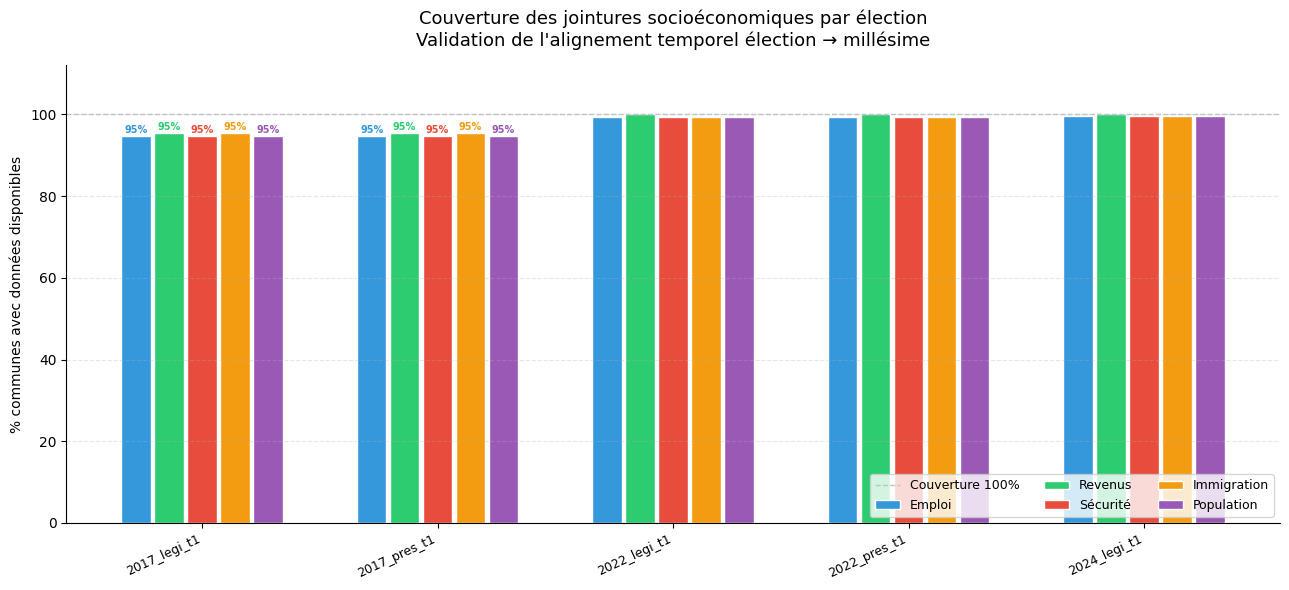

In [4]:
df_join = load("""
    SELECT id_election,
           COUNT(*) AS total_communes,
           SUM(CASE WHEN taux_chomage_2022 IS NOT NULL THEN 1 ELSE 0 END) AS ok_emploi,
           SUM(CASE WHEN revenu_median     IS NOT NULL THEN 1 ELSE 0 END) AS ok_revenu,
           SUM(CASE WHEN total_delits      IS NOT NULL THEN 1 ELSE 0 END) AS ok_securite,
           SUM(CASE WHEN nb_immigres       IS NOT NULL THEN 1 ELSE 0 END) AS ok_immigration,
           SUM(CASE WHEN population        IS NOT NULL THEN 1 ELSE 0 END) AS ok_population
    FROM master_ml
    GROUP BY id_election
    ORDER BY id_election
""")

sources = {"ok_emploi": "Emploi", "ok_revenu": "Revenus", "ok_securite": "Sécurité",
           "ok_immigration": "Immigration", "ok_population": "Population"}
for col in sources:
    df_join[col] = df_join[col] / df_join["total_communes"] * 100

fig, ax = plt.subplots(figsize=(13, 6))
x     = np.arange(len(df_join))
width = 0.14
colors = ["#3498db","#2ecc71","#e74c3c","#f39c12","#9b59b6"]

for i, (col, label) in enumerate(sources.items()):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, df_join[col], width=width * 0.9,
                  label=label, color=colors[i], edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        if h < 98:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                    f"{h:.0f}%", ha="center", fontsize=7, color=colors[i], fontweight="bold")

ax.axhline(100, color="#bdc3c7", linestyle="--", linewidth=1, label="Couverture 100%")
ax.set_xticks(x)
ax.set_xticklabels(df_join["id_election"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("% communes avec données disponibles")
ax.set_ylim(0, 112)
ax.set_title("Couverture des jointures socioéconomiques par élection\nValidation de l'alignement temporel élection → millésime",
             fontsize=13, pad=14)
ax.legend(loc="lower right", fontsize=9, ncol=3)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_ETL / "etl3_couverture_jointures.png", dpi=150)
plt.show()

BLOC 4 — ETL : Composition de l'indicateur sécurité

In [5]:
try:
    df_sec = load("""
        SELECT type_delit, annee, SUM(total_delits) AS nb
        FROM securite
        GROUP BY type_delit, annee
        ORDER BY annee, nb DESC
    """)
    annees = sorted(df_sec["annee"].unique())
    n      = len(annees)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=False)
    if n == 1:
        axes = [axes]
    palette = plt.cm.get_cmap("tab20", df_sec["type_delit"].nunique())

    for ax, annee in zip(axes, annees):
        sub    = df_sec[df_sec["annee"] == annee].sort_values("nb", ascending=True)
        colors = [palette(i) for i in range(len(sub))]
        bars   = ax.barh(sub["type_delit"], sub["nb"], color=colors, edgecolor="white", height=0.65)
        for bar, val in zip(bars, sub["nb"]):
            ax.text(bar.get_width() + sub["nb"].max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{int(val):,}".replace(",", " "), va="center", fontsize=8)
        ax.set_title(f"Année {annee}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Nombre de faits")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="x", linestyle="--", alpha=0.3)

    fig.suptitle("Composition de l'indicateur de sécurité par catégorie de délit\nRhône – justification de l'agrégation en total_delits",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_ETL / "etl4_composition_securite.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"Table securite non disponible : {e}")

Table securite non disponible : Execution failed on sql '
        SELECT type_delit, annee, SUM(total_delits) AS nb
        FROM securite
        GROUP BY type_delit, annee
        ORDER BY annee, nb DESC
    ': no such column: type_delit


## VISUALISATION EDA AVANT ML

BLOC 5 — EDA : Évolution des familles politiques

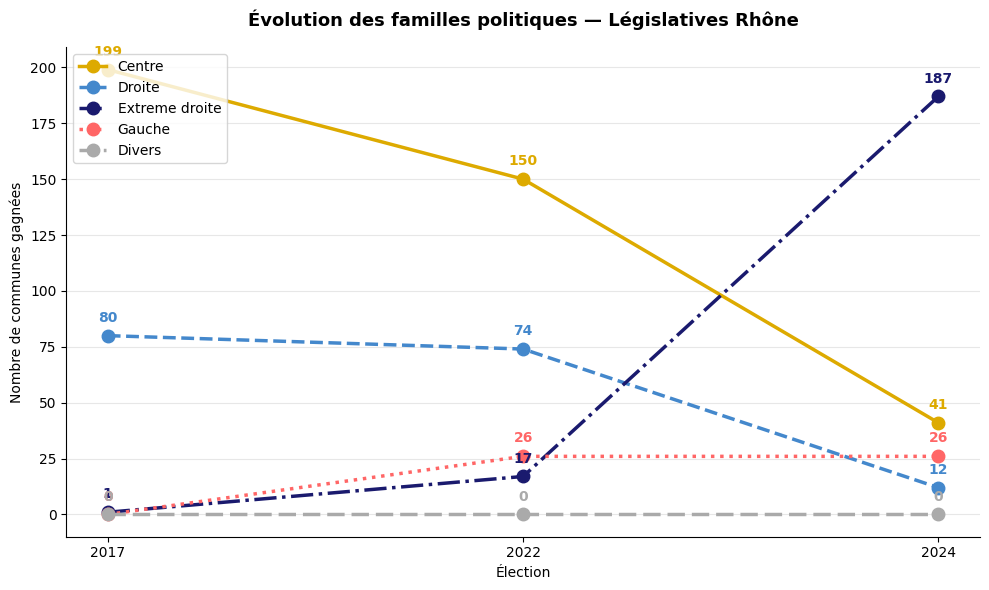

In [6]:
df_evol = load("SELECT id_election, type_election, famille_gagnante FROM master_ml")
df_evol["famille_regroupee"] = df_evol["famille_gagnante"].map(REGROUP).fillna("Divers")

elections_legi = sorted(df_evol[df_evol["type_election"] == "legi"]["id_election"].unique())
labels_legi    = [e.split("_")[0] for e in elections_legi]
familles       = list(COULEURS_REGROUP.keys())
linestyles     = ["-", "--", "-.", ":", (0, (5, 2))]

data_evol = {f: [(df_evol[df_evol["id_election"] == e]["famille_regroupee"] == f).sum()
                 for e in elections_legi]
             for f in familles}

fig, ax = plt.subplots(figsize=(10, 6))
for (famille, vals), ls in zip(data_evol.items(), linestyles):
    ax.plot(labels_legi, vals, marker="o", linewidth=2.5, markersize=9,
            color=COULEURS_REGROUP[famille], linestyle=ls, label=famille)
    for x_pos, y_pos in zip(labels_legi, vals):
        ax.annotate(str(y_pos), (x_pos, y_pos), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=10, fontweight="bold",
                    color=COULEURS_REGROUP[famille])

ax.set_title("Évolution des familles politiques — Législatives Rhône",
             fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Nombre de communes gagnées")
ax.set_xlabel("Élection")
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_EDA / "eda1_evolution_familles.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC 6 — EDA : Déséquilibre des classes

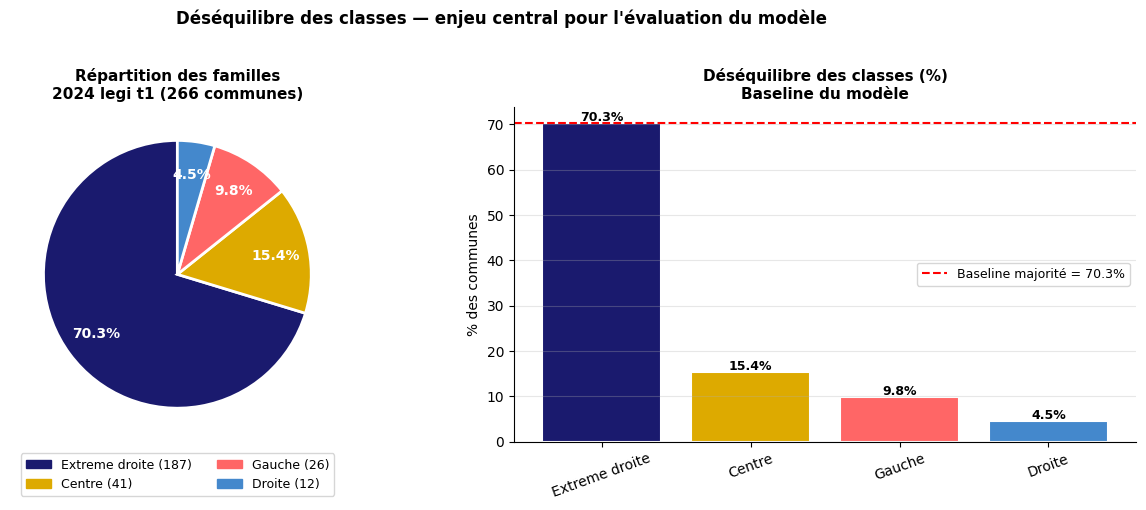

Baseline = 70.3%


In [7]:
df_cls = load("SELECT id_election, type_election, famille_gagnante FROM master_ml")
df_cls["famille_regroupee"] = df_cls["famille_gagnante"].map(REGROUP).fillna("Divers")

elections_legi = sorted(df_cls[df_cls["type_election"] == "legi"]["id_election"].unique())
id_2024        = elections_legi[-1]
df_2024        = df_cls[df_cls["id_election"] == id_2024].copy()
counts_24      = df_2024["famille_regroupee"].value_counts()
total_24       = len(df_2024)
baseline       = counts_24.max() / total_24 * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

wedge_colors = [COULEURS_REGROUP.get(f, "#AAAAAA") for f in counts_24.index]
wedges, texts, autotexts = axes[0].pie(
    counts_24.values, labels=None, autopct="%1.1f%%",
    colors=wedge_colors, startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
axes[0].set_title(f"Répartition des familles\n{id_2024.replace('_', ' ')} ({total_24} communes)",
                  fontsize=11, fontweight="bold")
legend_patches = [mpatches.Patch(color=COULEURS_REGROUP.get(f, "#AAAAAA"), label=f"{f} ({counts_24[f]})")
                  for f in counts_24.index]
axes[0].legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

bars = axes[1].bar(counts_24.index, [v / total_24 * 100 for v in counts_24.values],
                   color=[COULEURS_REGROUP.get(f, "#AAAAAA") for f in counts_24.index],
                   edgecolor="white", linewidth=1.5)
axes[1].axhline(y=baseline, color="red", linestyle="--", linewidth=1.5,
                label=f"Baseline majorité = {baseline:.1f}%")
axes[1].set_title("Déséquilibre des classes (%)\nBaseline du modèle", fontsize=11, fontweight="bold")
axes[1].set_ylabel("% des communes")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, [v / total_24 * 100 for v in counts_24.values]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Déséquilibre des classes — enjeu central pour l'évaluation du modèle",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_EDA / "eda2_desequilibre_classes.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Baseline = {baseline:.1f}%")

BLOC 7 — EDA : Valeurs manquantes

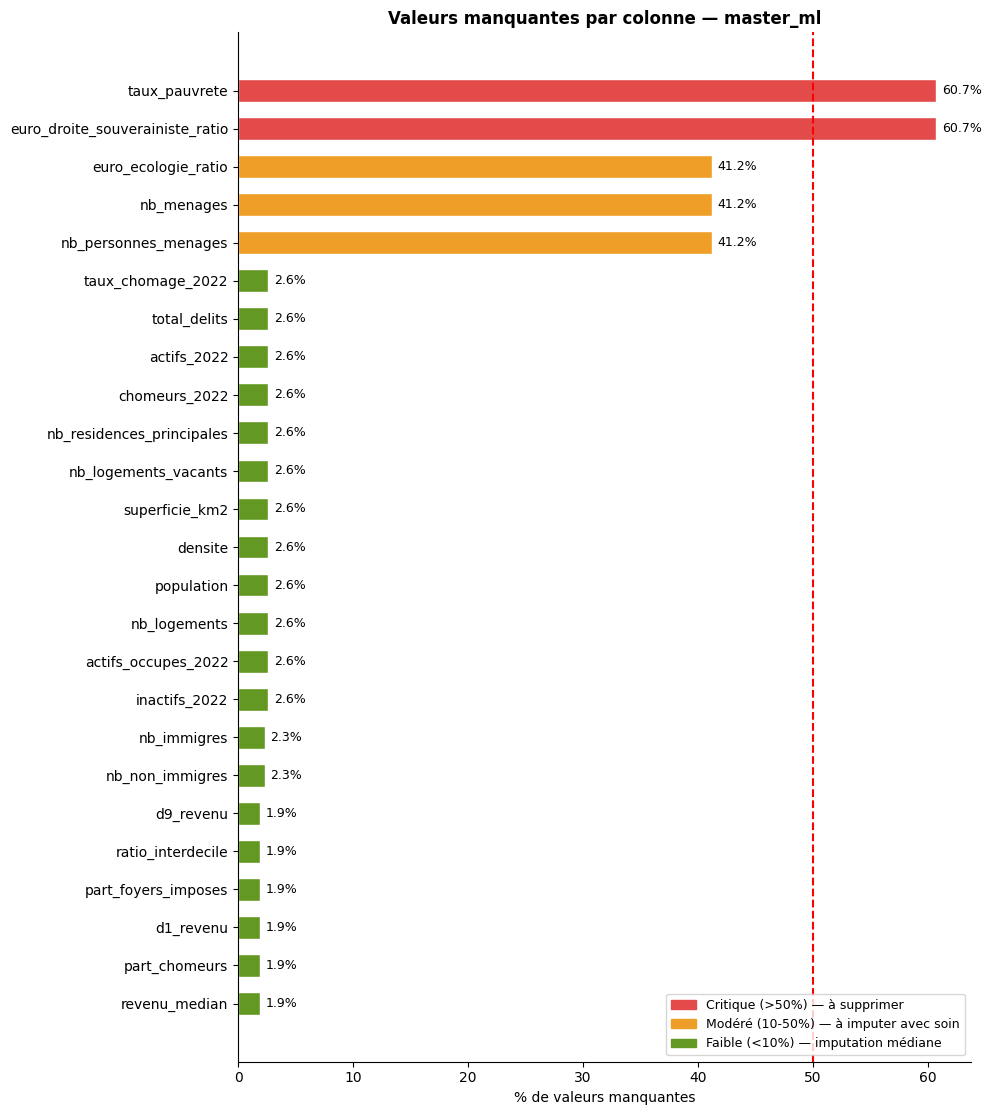

In [8]:
df_full = load("SELECT * FROM master_ml")
nan_pct = (df_full.isna().sum() / len(df_full) * 100).round(1)
nan_pct = nan_pct[nan_pct > 0].sort_values(ascending=True)

bar_colors_nan = ["#E24B4A" if v > 50 else "#EF9F27" if v > 10 else "#639922"
                  for v in nan_pct.values]

fig, ax = plt.subplots(figsize=(10, max(4, len(nan_pct) * 0.45)))
bars = ax.barh(nan_pct.index, nan_pct.values, color=bar_colors_nan, edgecolor="white", height=0.6)
ax.axvline(x=50, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne — master_ml", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, nan_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val}%", va="center", fontsize=9)
legend_patches = [
    mpatches.Patch(color="#E24B4A", label="Critique (>50%) — à supprimer"),
    mpatches.Patch(color="#EF9F27", label="Modéré (10-50%) — à imputer avec soin"),
    mpatches.Patch(color="#639922", label="Faible (<10%) — imputation médiane"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_EDA / "eda3_nan.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC 8 — EDA : Stabilité territoriale

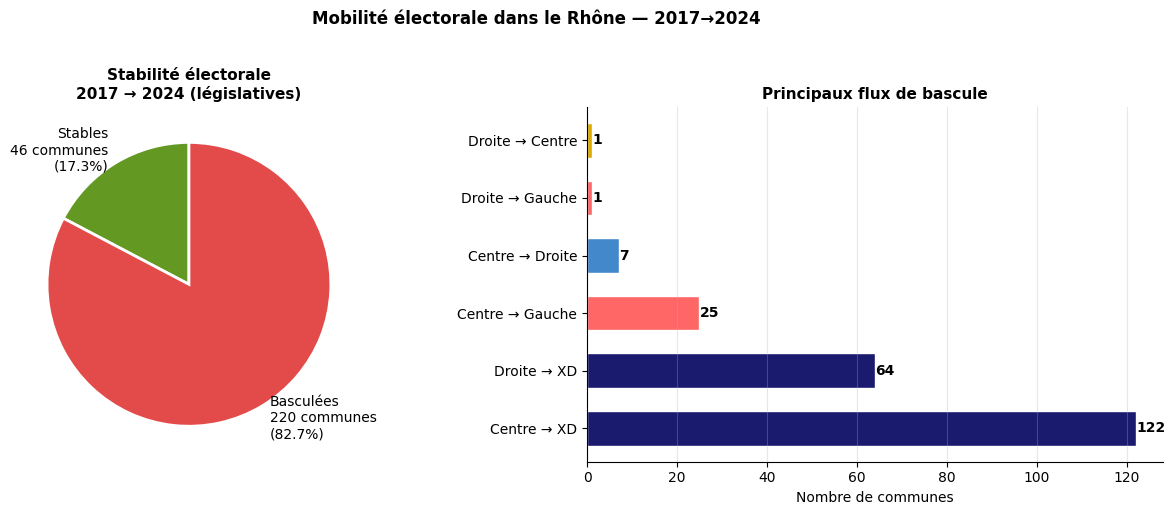

Stables : 46 | Basculées : 220


In [9]:
df_stab = load("SELECT code_commune, id_election, type_election, famille_gagnante FROM master_ml WHERE type_election = 'legi'")
df_stab["famille_regroupee"] = df_stab["famille_gagnante"].map(REGROUP).fillna("Divers")

elections = sorted(df_stab["id_election"].unique())
id_debut, id_fin = elections[0], elections[-1]

df_pivot = df_stab.pivot_table(index="code_commune", columns="id_election",
                                values="famille_regroupee", aggfunc="first")
df_pivot = df_pivot.dropna(subset=[id_debut, id_fin])
df_pivot["stable"] = df_pivot[id_debut] == df_pivot[id_fin]

nb_stable   = df_pivot["stable"].sum()
nb_instable = (~df_pivot["stable"]).sum()
total_com   = len(df_pivot)

df_bascule          = df_pivot[~df_pivot["stable"]].copy()
df_bascule["flux"]  = (df_bascule[id_debut].str.replace("Extreme droite", "XD")
                       + " → "
                       + df_bascule[id_fin].str.replace("Extreme droite", "XD"))
flux_counts = df_bascule["flux"].value_counts().head(8)

annee_debut, annee_fin = id_debut.split("_")[0], id_fin.split("_")[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(
    [nb_stable, nb_instable],
    labels=[f"Stables\n{nb_stable} communes\n({nb_stable/total_com*100:.1f}%)",
            f"Basculées\n{nb_instable} communes\n({nb_instable/total_com*100:.1f}%)"],
    colors=["#639922", "#E24B4A"], startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 10}
)
axes[0].set_title(f"Stabilité électorale\n{annee_debut} → {annee_fin} (législatives)",
                  fontsize=11, fontweight="bold")

bar_colors_flux = [COULEURS_REGROUP.get(f.split(" → ")[1].replace("XD", "Extreme droite"), "#AAAAAA")
                   for f in flux_counts.index]
bars = axes[1].barh(flux_counts.index, flux_counts.values,
                    color=bar_colors_flux, edgecolor="white", height=0.6)
axes[1].set_title("Principaux flux de bascule", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Nombre de communes")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(axis="x", alpha=0.3)
for bar, val in zip(bars, flux_counts.values):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=10, fontweight="bold")

fig.suptitle(f"Mobilité électorale dans le Rhône — {annee_debut}→{annee_fin}",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_EDA / "eda4_stabilite.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Stables : {nb_stable} | Basculées : {nb_instable}")

BLOC 9 — Electoral : Participation par type d'élection

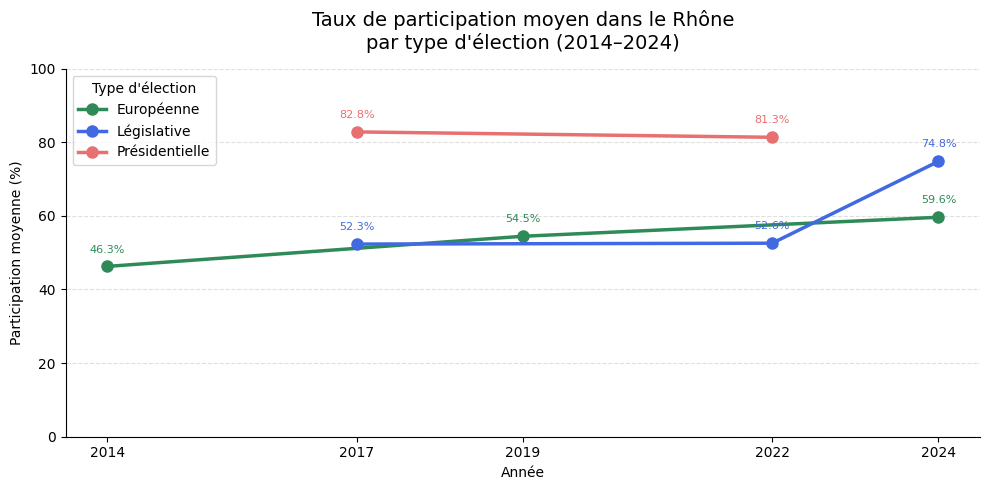

In [10]:
df_part = load("""
    SELECT id_election, annee, type_election, AVG(taux_participation) AS participation
    FROM general_communes
    GROUP BY id_election, annee, type_election
    ORDER BY annee, type_election
""")
labels_e  = {"pres": "Présidentielle", "legi": "Législative", "euro": "Européenne"}
couleurs_e = {"Présidentielle": "#E87070", "Législative": "#4169E1", "Européenne": "#2E8B57"}
df_part["label"] = df_part["type_election"].map(labels_e).fillna(df_part["type_election"])

fig, ax = plt.subplots(figsize=(10, 5))
for election_type, grp in df_part.groupby("label"):
    ax.plot(grp["annee"], grp["participation"], marker="o", linewidth=2.5, markersize=8,
            color=couleurs_e.get(election_type, "#999"), label=election_type)
    for _, row in grp.iterrows():
        ax.annotate(f"{row['participation']:.1f}%", (row["annee"], row["participation"]),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8,
                    color=couleurs_e.get(election_type, "#999"))

ax.set_title("Taux de participation moyen dans le Rhône\npar type d'élection (2014–2024)",
             fontsize=14, pad=14)
ax.set_xlabel("Année")
ax.set_ylabel("Participation moyenne (%)")
ax.set_ylim(0, 100)
ax.legend(title="Type d'élection")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_xticks(df_part["annee"].unique())
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ELECTORAL / "elec1_participation.png", dpi=150)
plt.show()

BLOC 10 — Electoral : Familles gagnantes par commune

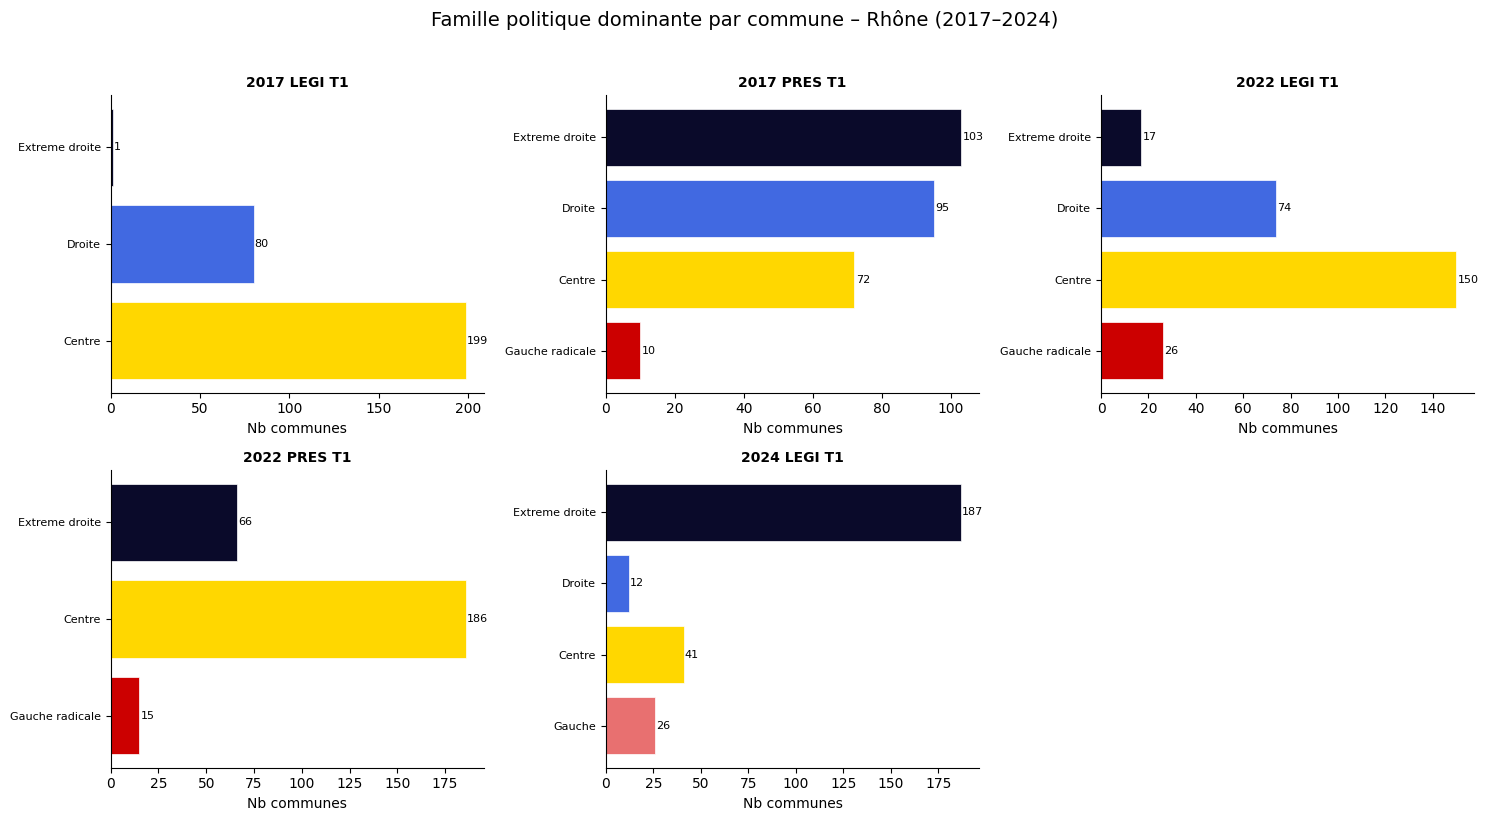

In [11]:
df_fam = load("""
    SELECT id_election, annee, type_election, famille_gagnante, COUNT(*) AS nb_communes
    FROM master_ml
    GROUP BY id_election, annee, type_election, famille_gagnante
    ORDER BY annee, famille_gagnante
""")

elections = df_fam["id_election"].unique()
ncols = 3
nrows = (len(elections) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, elec in enumerate(elections):
    sub = df_fam[df_fam["id_election"] == elec].copy()
    sub["famille_gagnante"] = pd.Categorical(sub["famille_gagnante"],
                                              categories=FAMILLES_ORDER, ordered=True)
    sub    = sub.sort_values("famille_gagnante")
    colors = [PALETTE_FAMILLES.get(f, "#CCCCCC") for f in sub["famille_gagnante"]]
    ax     = axes[i]
    bars   = ax.barh(sub["famille_gagnante"], sub["nb_communes"],
                     color=colors, edgecolor="white", linewidth=0.5)
    for bar, nb in zip(bars, sub["nb_communes"]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                str(nb), va="center", fontsize=8)
    ax.set_title(elec.replace("_", " ").upper(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Nb communes")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Famille politique dominante par commune – Rhône (2017–2024)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUT_ELECTORAL / "elec2_familles_gagnantes.png", dpi=150, bbox_inches="tight")
plt.show()

BLOC 11 — Electoral : Répartition des voix par famille

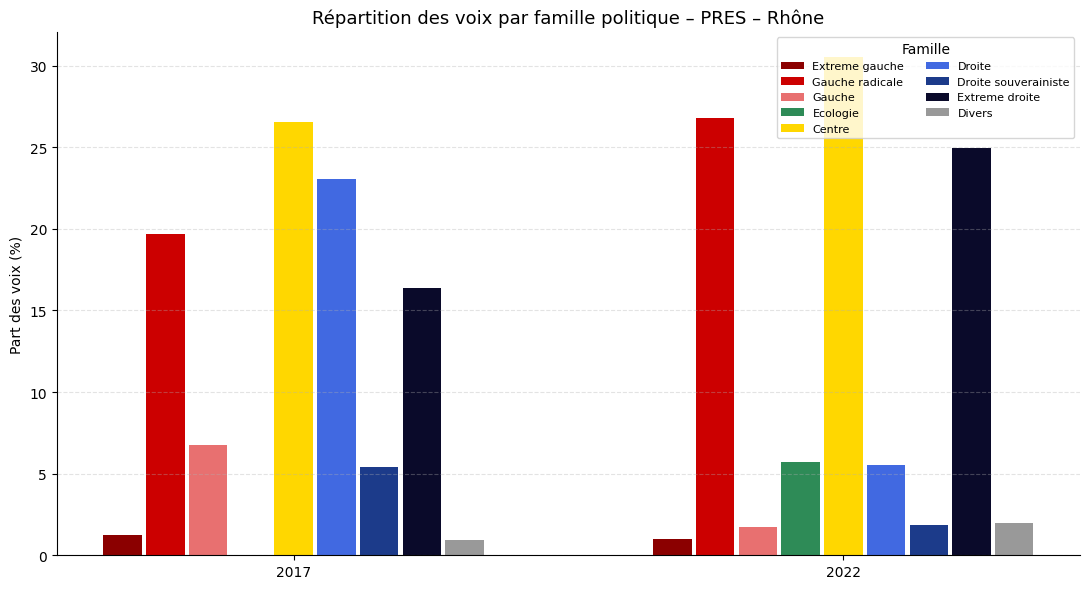

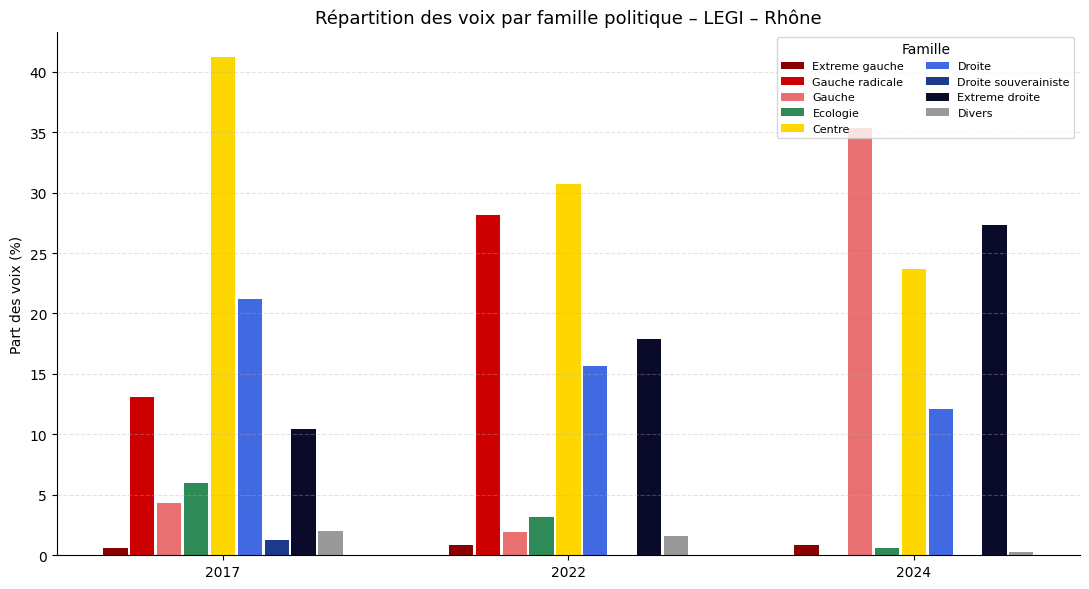

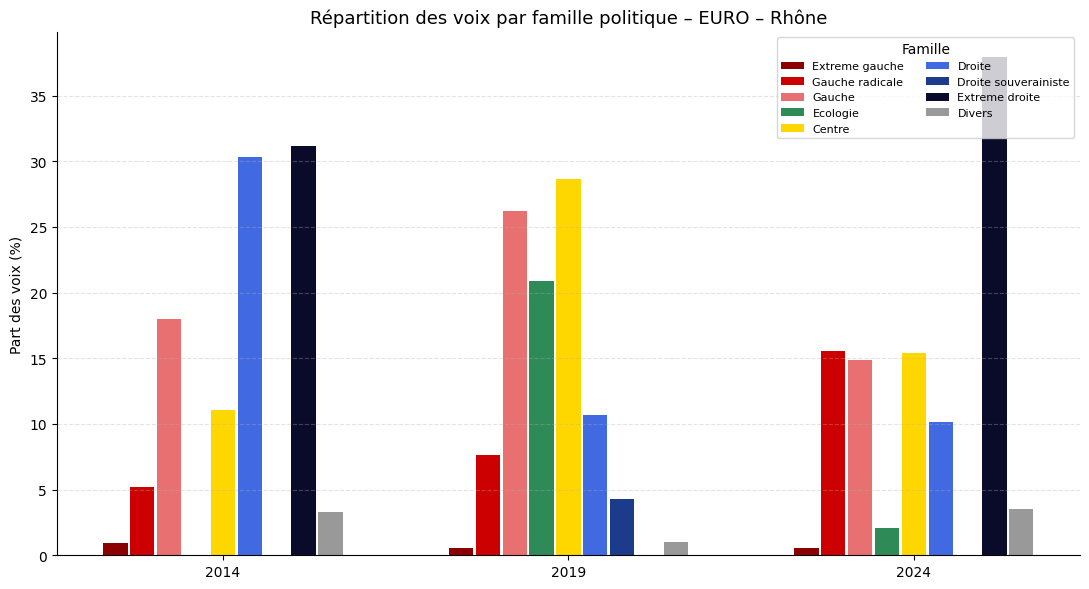

In [12]:
df_voix = load("""
    SELECT id_election, annee, type_election, famille_politique, SUM(voix) AS voix_total
    FROM candidats_communes
    WHERE famille_politique NOT IN ('Inconnu')
    GROUP BY id_election, annee, type_election, famille_politique
""")
totaux = (df_voix.groupby(["id_election", "annee", "type_election"])["voix_total"]
          .sum().rename("total").reset_index())
df_voix = df_voix.merge(totaux, on=["id_election", "annee", "type_election"])
df_voix["part"] = df_voix["voix_total"] / df_voix["total"] * 100

for elec_type in ["pres", "legi", "euro"]:
    sub = df_voix[df_voix["type_election"] == elec_type].copy()
    if sub.empty:
        continue
    pivot = sub.pivot_table(index="famille_politique", columns="annee",
                             values="part", aggfunc="sum").fillna(0)
    pivot = pivot.reindex([f for f in FAMILLES_ORDER if f in pivot.index])

    fig, ax = plt.subplots(figsize=(11, 6))
    x     = range(len(pivot.columns))
    width = 0.7 / max(len(pivot.index), 1)
    for j, famille in enumerate(pivot.index):
        offset = (j - len(pivot.index) / 2) * width + width / 2
        ax.bar([xi + offset for xi in x], pivot.loc[famille], width=width * 0.9,
               color=PALETTE_FAMILLES.get(famille, "#CCCCCC"), label=famille)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_ylabel("Part des voix (%)")
    ax.set_title(f"Répartition des voix par famille politique – {elec_type.upper()} – Rhône", fontsize=13)
    ax.legend(loc="upper right", fontsize=8, ncol=2, title="Famille")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUT_ELECTORAL / f"elec3_scores_{elec_type}.png", dpi=150)
    plt.show()

BLOC 12 — Electoral : Revenu médian par famille (boxplot)

C:\Users\NIAMBELE Siata\AppData\Local\Temp\ipykernel_3044\1706489956.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rev, x="famille_gagnante", y="revenu_median", order=ordre, palette=palette,
C:\Users\NIAMBELE Siata\AppData\Local\Temp\ipykernel_3044\1706489956.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)


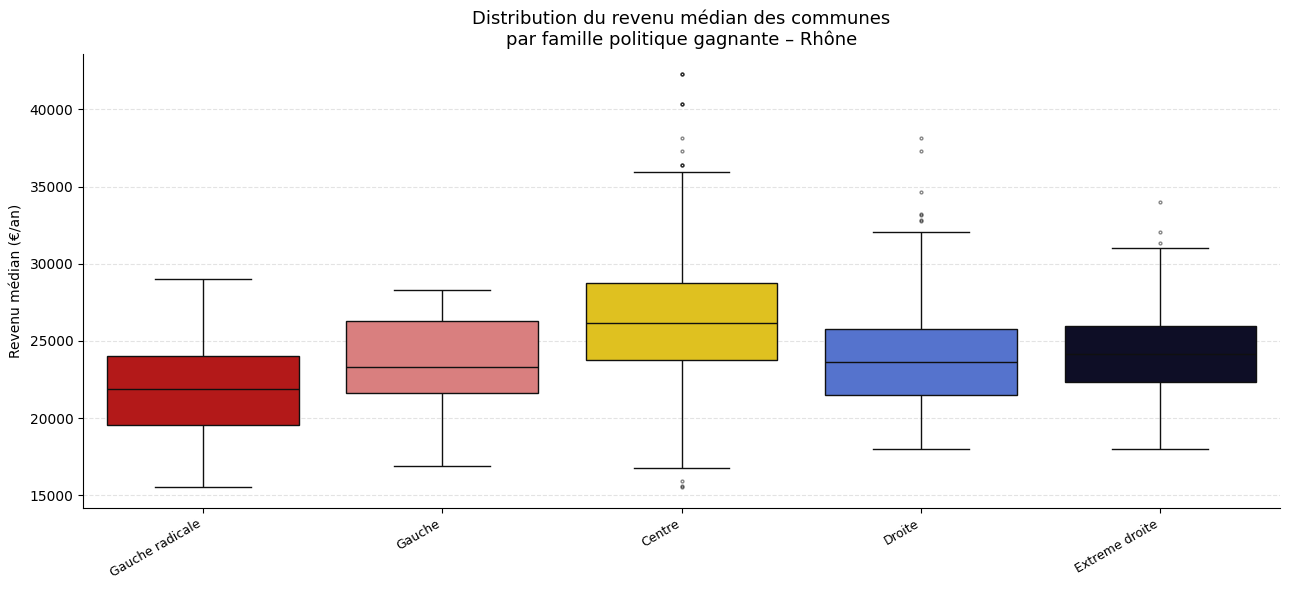

In [13]:
df_rev = load("""
    SELECT famille_gagnante, revenu_median, annee, type_election
    FROM master_ml
    WHERE revenu_median IS NOT NULL AND famille_gagnante NOT IN ('Inconnu')
""")

ordre   = [f for f in FAMILLES_ORDER if f in df_rev["famille_gagnante"].unique()]
palette = {f: PALETTE_FAMILLES[f] for f in ordre}

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_rev, x="famille_gagnante", y="revenu_median", order=ordre, palette=palette,
            flierprops={"marker": ".", "markersize": 4, "alpha": 0.5}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_title("Distribution du revenu médian des communes\npar famille politique gagnante – Rhône", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Revenu médian (€/an)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ELECTORAL / "elec4_revenu_famille.png", dpi=150)
plt.show()

BLOC 13 — Electoral : Heatmap corrélations socioéco × scores politiques

Lignes : 795 | Colonnes : 17


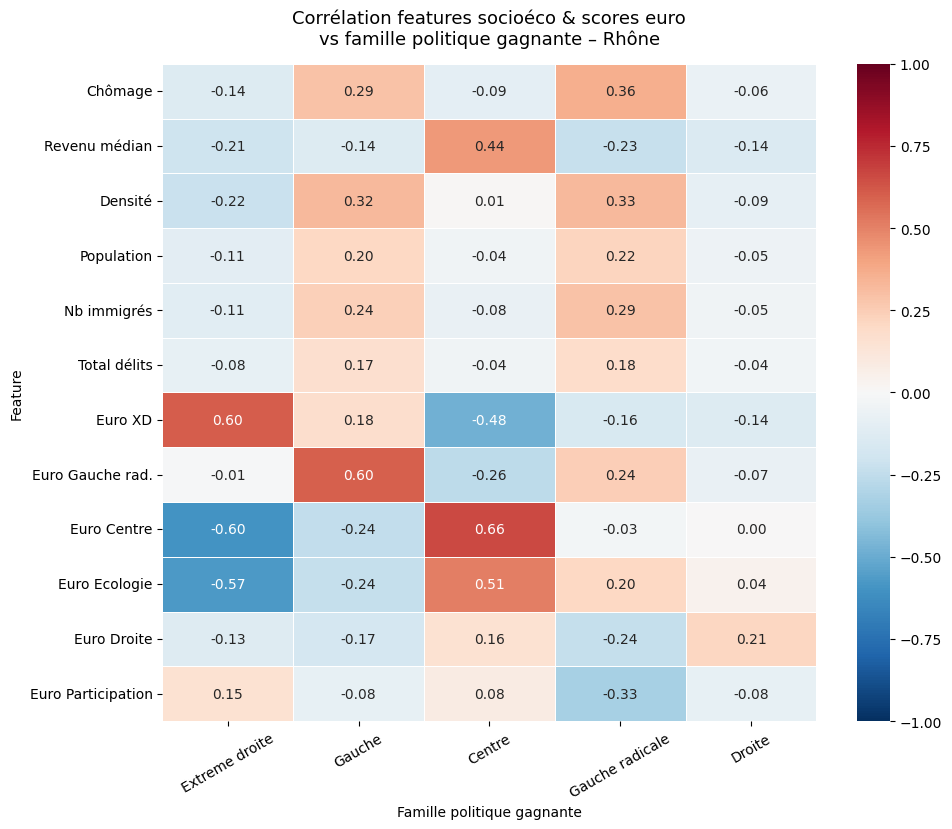

In [14]:
df_feat = load("""
    SELECT m.taux_chomage_2022,
           m.revenu_median,
           m.densite,
           m.population,
           m.nb_immigres,
           m.total_delits,
           m.euro_extreme_droite_ratio,
           m.euro_gauche_radicale_ratio,
           m.euro_centre_ratio,
           m.euro_ecologie_ratio,
           m.euro_droite_ratio,
           m.euro_taux_participation,
           m.famille_gagnante
    FROM master_ml m
    WHERE m.taux_chomage_2022 IS NOT NULL
      AND m.famille_gagnante NOT IN ('Inconnu')
""")

df_feat = df_feat.apply(lambda col: pd.to_numeric(col, errors="coerce")
                        if col.name != "famille_gagnante" else col)

familles_dummies = pd.get_dummies(df_feat["famille_gagnante"], prefix="")
familles_dummies.columns = [c.strip("_") for c in familles_dummies.columns]

df_combined = pd.concat([
    df_feat.drop(columns=["famille_gagnante"]),
    familles_dummies
], axis=1).dropna()

print(f"Lignes : {len(df_combined)} | Colonnes : {df_combined.shape[1]}")

features = [c for c in df_combined.columns if c not in familles_dummies.columns]
partis   = list(familles_dummies.columns)

corr_matrix = df_combined[features + partis].corr()
corr_fp = corr_matrix.loc[features, partis]

rename_features = {
    "taux_chomage_2022"         : "Chômage",
    "revenu_median"             : "Revenu médian",
    "densite"                   : "Densité",
    "population"                : "Population",
    "nb_immigres"               : "Nb immigrés",
    "total_delits"              : "Total délits",
    "euro_extreme_droite_ratio" : "Euro XD",
    "euro_gauche_radicale_ratio": "Euro Gauche rad.",
    "euro_centre_ratio"         : "Euro Centre",
    "euro_ecologie_ratio"       : "Euro Ecologie",
    "euro_droite_ratio"         : "Euro Droite",
    "euro_taux_participation"   : "Euro Participation",
}
corr_fp = corr_fp.rename(index=rename_features)

ordre_partis = sorted(partis, key=lambda p: corr_fp[p].abs().sum(), reverse=True)
corr_fp = corr_fp[ordre_partis]

fig, ax = plt.subplots(figsize=(max(10, len(partis) * 1.5), max(7, len(features) * 0.7)))
sns.heatmap(
    corr_fp,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, annot_kws={"size": 10}
)
ax.set_title("Corrélation features socioéco & scores euro\nvs famille politique gagnante – Rhône",
             fontsize=13, pad=14)
ax.set_xlabel("Famille politique gagnante")
ax.set_ylabel("Feature")
ax.tick_params(axis="x", rotation=30, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig(OUT_ELECTORAL / "elec7_heatmap_features_partis.png", dpi=150)
plt.show()

BLOC 14 — Electoral : Densité vs vote extrême droite (hexbin)

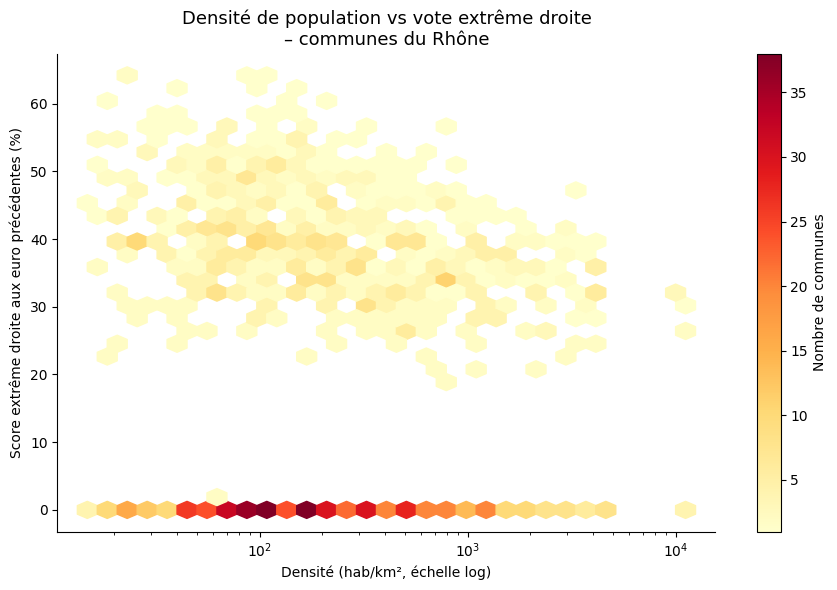

In [15]:
df_hex = load("""
    SELECT densite, euro_extreme_droite_ratio
    FROM master_ml
    WHERE densite IS NOT NULL AND euro_extreme_droite_ratio IS NOT NULL AND densite > 0
""")

fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(df_hex["densite"], df_hex["euro_extreme_droite_ratio"],
               gridsize=30, cmap="YlOrRd", mincnt=1, xscale="log")
plt.colorbar(hb, ax=ax, label="Nombre de communes")
ax.set_xlabel("Densité (hab/km², échelle log)")
ax.set_ylabel("Score extrême droite aux euro précédentes (%)")
ax.set_title("Densité de population vs vote extrême droite\n– communes du Rhône", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_ELECTORAL / "elec6_densite_exd.png", dpi=150)
plt.show()

## VISUALISATION ML

In [16]:
import joblib
from pathlib import Path

BASE        = Path(r"C:\Users\NIAMBELE Siata\Desktop\MSPR2")
MODELS_DIR  = BASE / "04_outputs" / "models"
OUTPUTS_DIR = BASE / "04_outputs" / "ml"

modeles_combined = {
    "Random Forest"      : joblib.load(MODELS_DIR / "random_forest_combined.joblib"),
    "Gradient Boosting"  : joblib.load(MODELS_DIR / "gradient_boosting_combined.joblib"),
    "Logistic Regression": joblib.load(MODELS_DIR / "logistic_regression_combined.joblib"),
    "KNN"                : joblib.load(MODELS_DIR / "knn_combined.joblib"),
}
le_combined       = joblib.load(MODELS_DIR / "le_combined.joblib")
X_combined        = joblib.load(MODELS_DIR / "X_combined.pkl")
X_train_c         = joblib.load(MODELS_DIR / "X_train_c.pkl")
X_test_c          = joblib.load(MODELS_DIR / "X_test_c.pkl")
y_combined        = joblib.load(MODELS_DIR / "y_combined.pkl")
y_train_c         = joblib.load(MODELS_DIR / "y_train_c.pkl")
y_test_c          = joblib.load(MODELS_DIR / "y_test_c.pkl")
df_bilan_combined = joblib.load(MODELS_DIR / "df_bilan_combined.pkl")

COULEURS = {
    "Centre"        : "#DDAA00",
    "Droite"        : "#4488CC",
    "Extreme droite": "#1A1A6E",
    "Gauche"        : "#FF6666",
    "Divers"        : "#AAAAAA",
}

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

print("Tout rechargé — prêt pour les visualisations.")
print(f"Classes : {list(le_combined.classes_)}")
print(f"X_combined : {X_combined.shape}")

Tout rechargé — prêt pour les visualisations.
Classes : ['Centre', 'Droite', 'Extreme droite', 'Gauche']
X_combined : (266, 154)


BLOC VIZ 1 — Courbes d'apprentissage (learning curves) par modèle

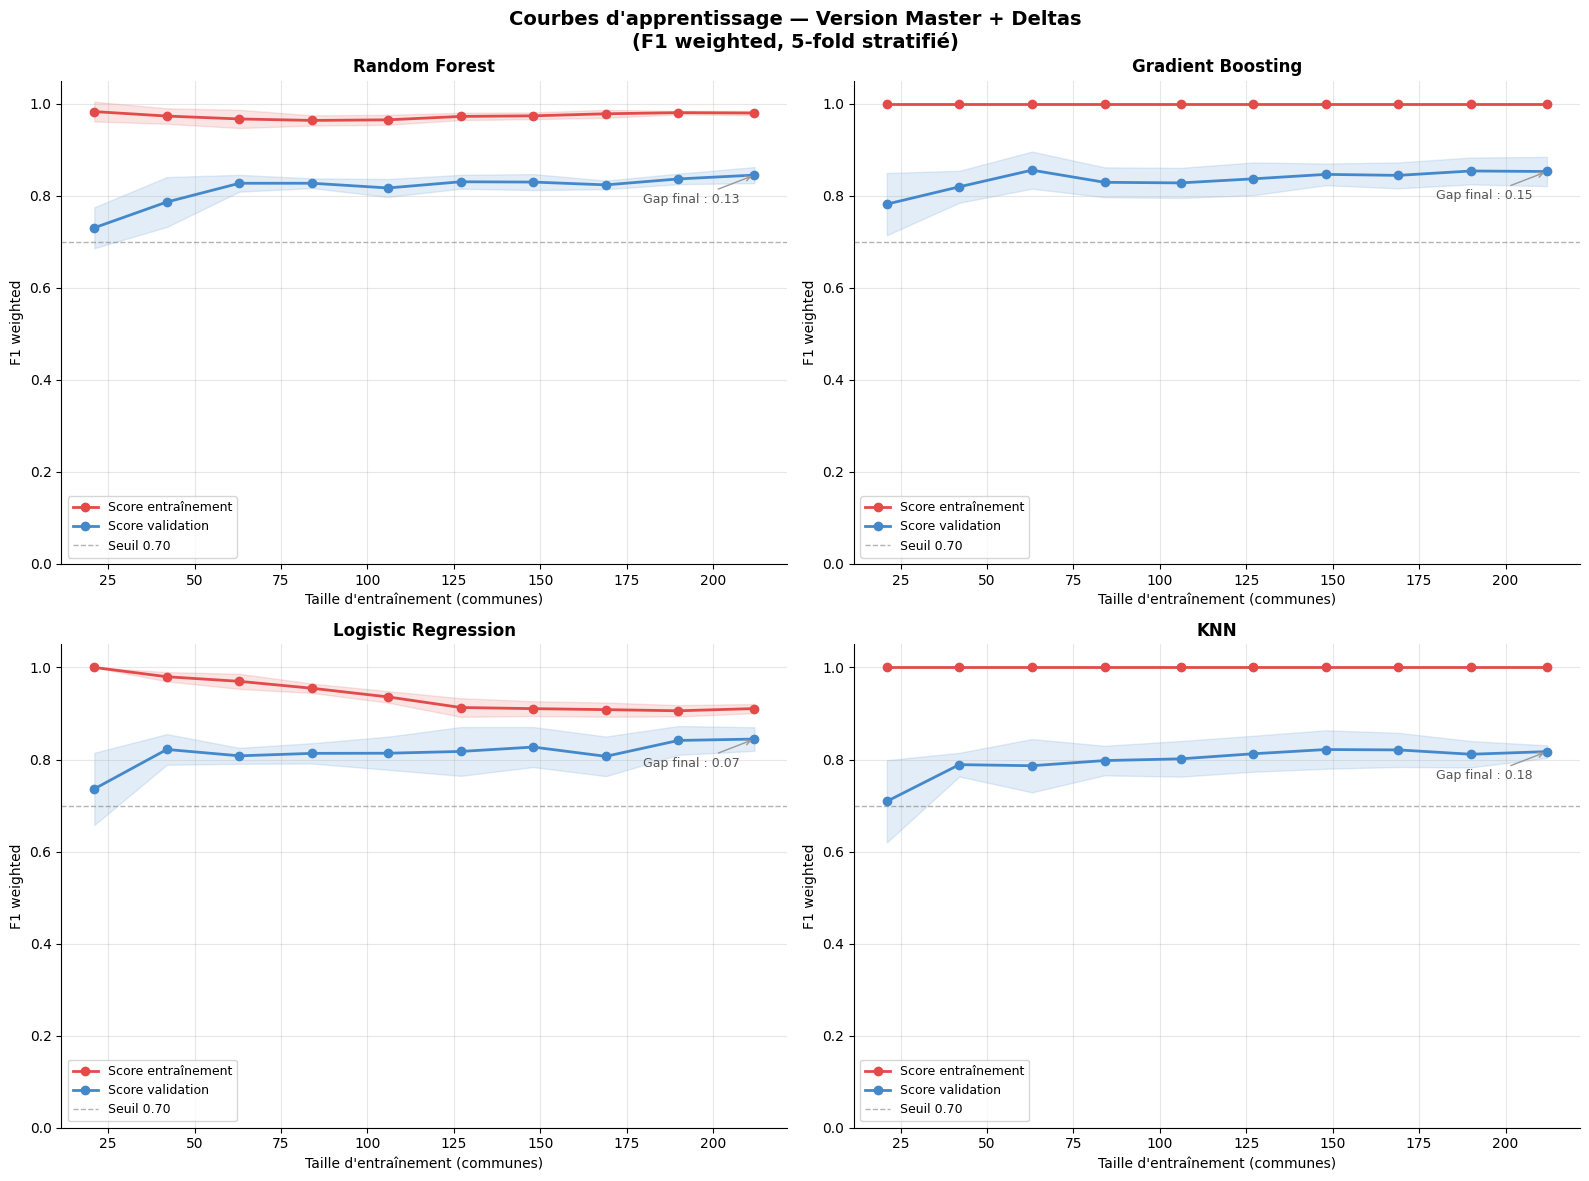

In [17]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (nom, pipeline) in enumerate(modeles_combined.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_combined, y_combined,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="f1_weighted",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax = axes[i]
    ax.plot(train_sizes, train_mean, "o-", color="#E24B4A", linewidth=2, label="Score entraînement")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color="#E24B4A")
    ax.plot(train_sizes, val_mean, "o-", color="#4488CC", linewidth=2, label="Score validation")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color="#4488CC")
    ax.axhline(y=0.7, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Seuil 0.70")
    ax.set_title(nom, fontsize=12, fontweight="bold")
    ax.set_xlabel("Taille d'entraînement (communes)")
    ax.set_ylabel("F1 weighted")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    gap = train_mean[-1] - val_mean[-1]
    ax.annotate(f"Gap final : {gap:.2f}",
                xy=(train_sizes[-1], val_mean[-1]),
                xytext=(-80, -20), textcoords="offset points",
                fontsize=9, color="#555",
                arrowprops=dict(arrowstyle="->", color="#999"))

plt.suptitle("Courbes d'apprentissage — Version Master + Deltas\n(F1 weighted, 5-fold stratifié)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_learning_curves.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC VIZ 2 — Matrices de confusion (4 modèles)

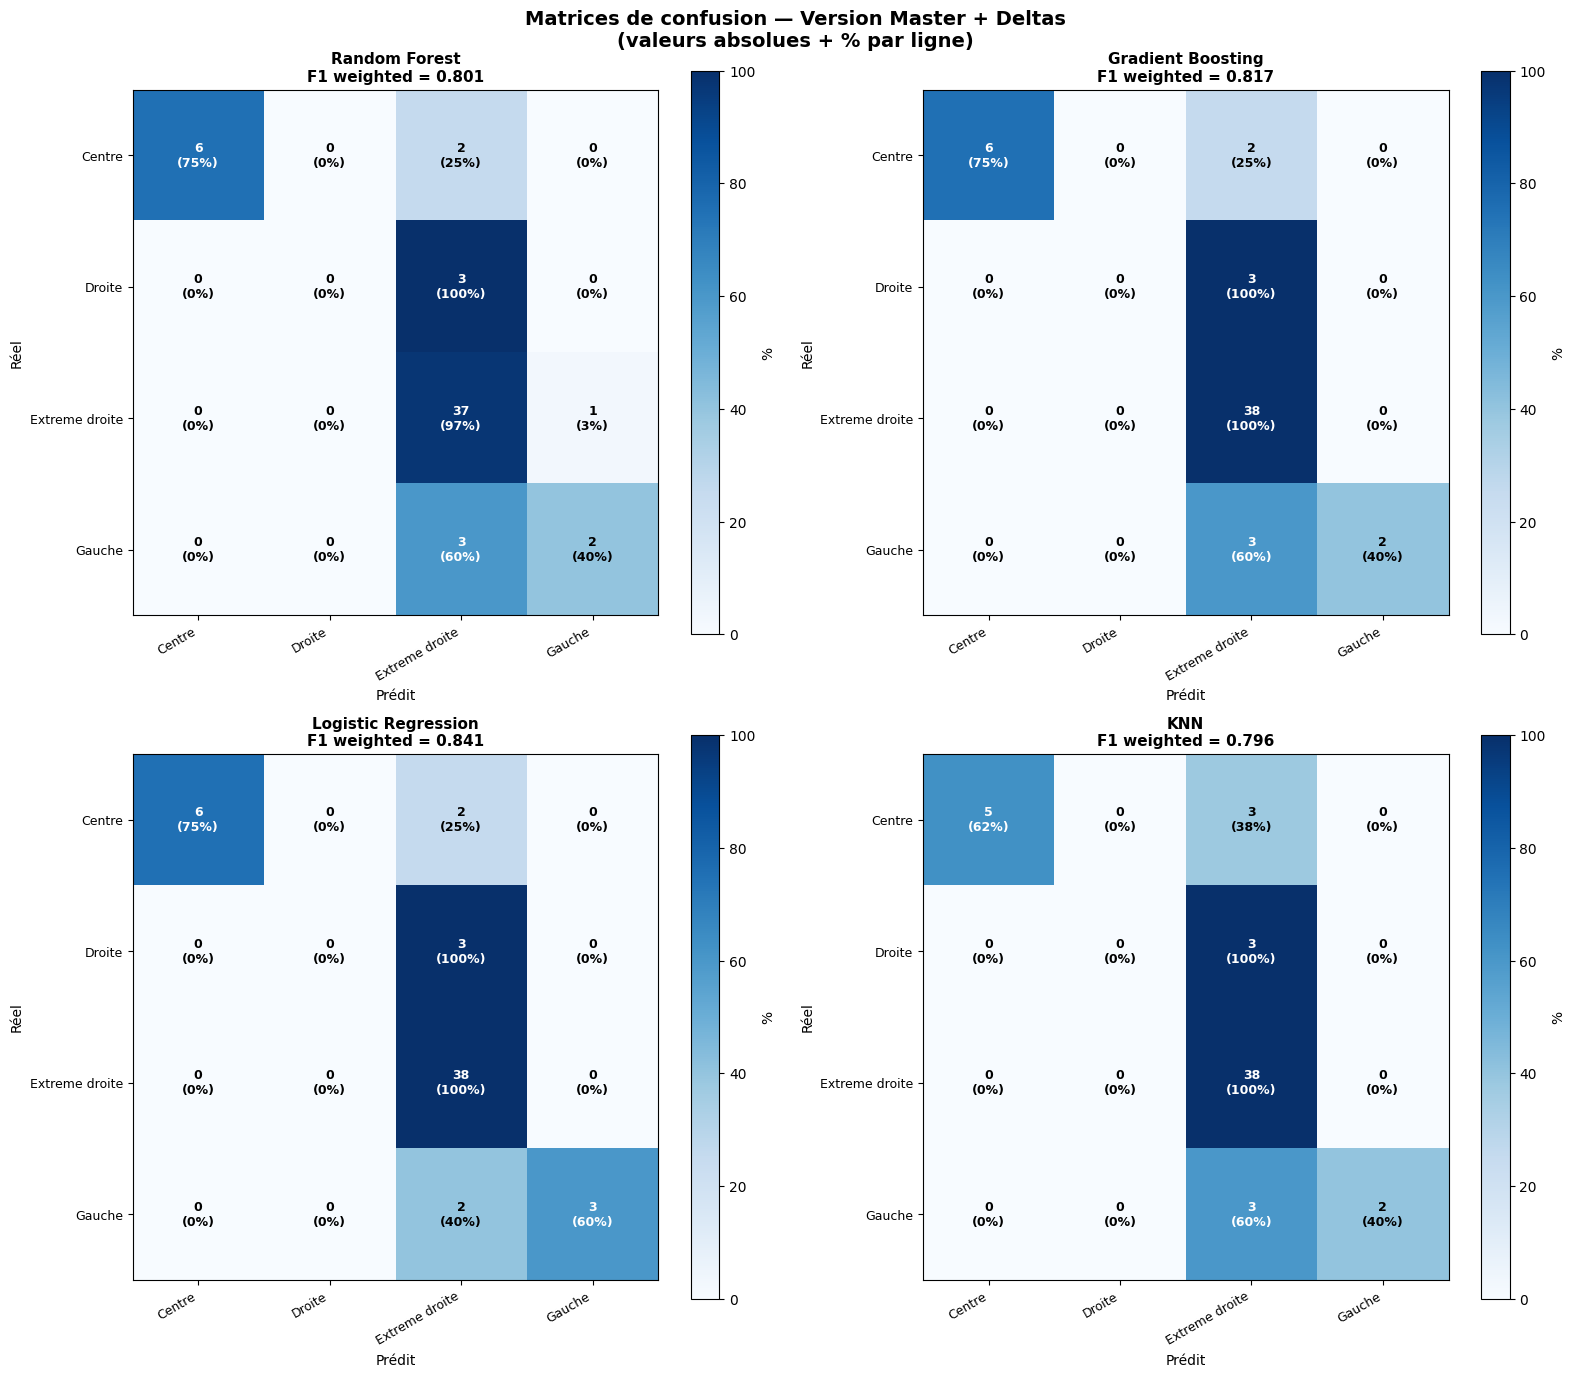

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (nom, pipeline) in enumerate(modeles_combined.items()):
    y_pred_cm = pipeline.predict(X_test_c)
    cm = confusion_matrix(y_test_c, y_pred_cm)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    ax = axes[i]
    im = ax.imshow(cm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label="%")

    classes = le_combined.classes_
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)

    for row in range(cm_pct.shape[0]):
        for col in range(cm_pct.shape[1]):
            color = "white" if cm_pct[row, col] > 50 else "black"
            ax.text(col, row, f"{cm[row,col]}\n({cm_pct[row,col]:.0f}%)",
                    ha="center", va="center", fontsize=9, color=color, fontweight="bold")

    f1_nom = f1_score(y_test_c, y_pred_cm, average="weighted", zero_division=0)
    ax.set_title(f"{nom}\nF1 weighted = {f1_nom:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.suptitle("Matrices de confusion — Version Master + Deltas\n(valeurs absolues + % par ligne)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC VIZ 3 — F1 par classe et par modèle

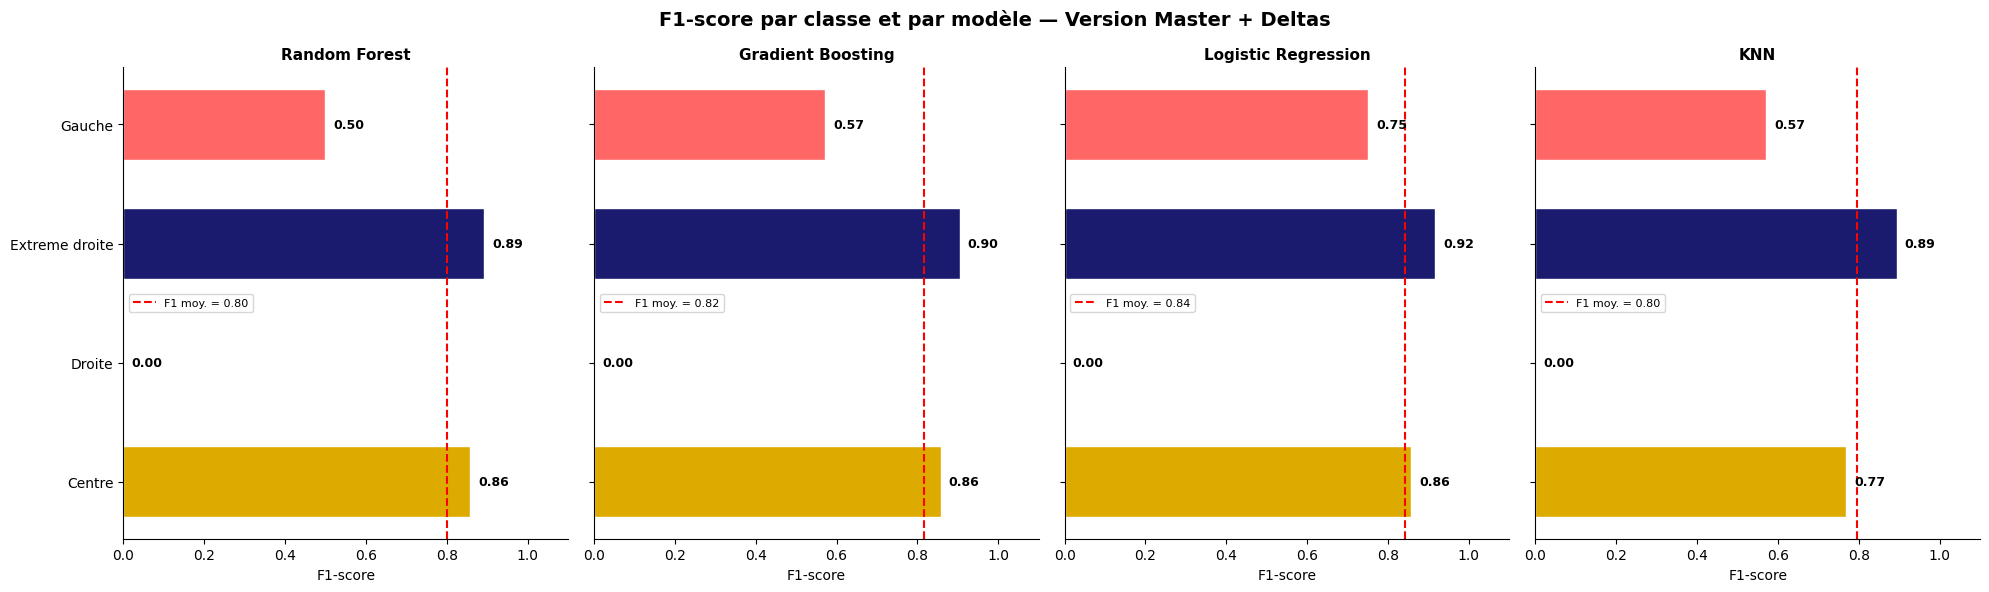

In [19]:
from sklearn.metrics import classification_report

fig, axes = plt.subplots(1, len(modeles_combined), figsize=(20, 6), sharey=True)

for i, (nom, pipeline) in enumerate(modeles_combined.items()):
    y_pred_cl = pipeline.predict(X_test_c)
    report    = classification_report(y_test_c, y_pred_cl,
                                       target_names=le_combined.classes_,
                                       output_dict=True, zero_division=0)
    classes   = le_combined.classes_
    f1_scores = [report[c]["f1-score"] for c in classes]
    colors    = [COULEURS.get(c, "#AAAAAA") for c in classes]

    ax   = axes[i]
    bars = ax.barh(classes, f1_scores, color=colors, edgecolor="white", height=0.6)
    ax.axvline(x=report["weighted avg"]["f1-score"], color="red",
               linestyle="--", linewidth=1.5, label=f"F1 moy. = {report['weighted avg']['f1-score']:.2f}")
    ax.set_xlim(0, 1.1)
    ax.set_title(nom, fontsize=11, fontweight="bold")
    ax.set_xlabel("F1-score")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, f1_scores):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9, fontweight="bold")

plt.suptitle("F1-score par classe et par modèle — Version Master + Deltas",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_f1_par_classe.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC VIZ 4 — Comparaison CV vs Test (surapprentissage)

df_bilan et df_bilan_deltas rechargés.


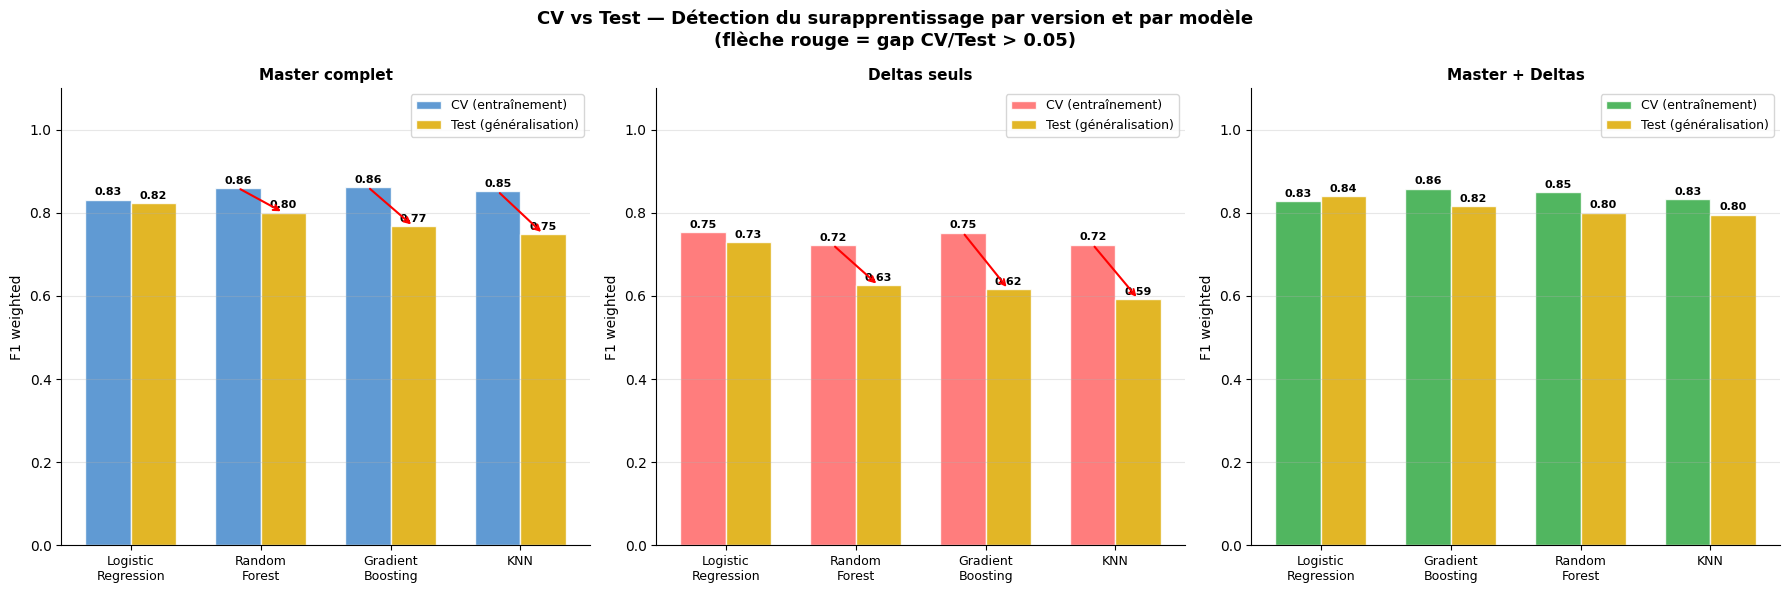

In [21]:
df_bilan        = joblib.load(MODELS_DIR / "df_bilan.pkl")
df_bilan_deltas = joblib.load(MODELS_DIR / "df_bilan_deltas.pkl")
print("df_bilan et df_bilan_deltas rechargés.")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
versions = [
    ("Master complet",  df_bilan,         "#4488CC"),
    ("Deltas seuls",    df_bilan_deltas,   "#FF6666"),
    ("Master + Deltas", df_bilan_combined, "#33AA44"),
]

for ax, (titre, df_v, color) in zip(axes, versions):
    modeles_noms = df_v["modele"].tolist()
    scores_cv    = df_v["score_cv"].tolist()
    scores_test  = df_v["f1_weighted"].tolist()
    x = np.arange(len(modeles_noms))
    w = 0.35

    bars1 = ax.bar(x - w/2, scores_cv,   width=w, color=color,    alpha=0.85,
                   label="CV (entraînement)", edgecolor="white")
    bars2 = ax.bar(x + w/2, scores_test, width=w, color="#DDAA00", alpha=0.85,
                   label="Test (généralisation)", edgecolor="white")

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.2f}",
                ha="center", fontsize=8, fontweight="bold")

    # Flèches surapprentissage
    for xi, cv, test in zip(x, scores_cv, scores_test):
        gap = cv - test
        if abs(gap) > 0.05:
            ax.annotate("", xy=(xi + w/2, test), xytext=(xi - w/2, cv),
                        arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" ", "\n") for m in modeles_noms], fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.set_ylabel("F1 weighted")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("CV vs Test — Détection du surapprentissage par version et par modèle\n(flèche rouge = gap CV/Test > 0.05)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_cv_vs_test.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC VIZ 5 — Importance des features (Random Forest)

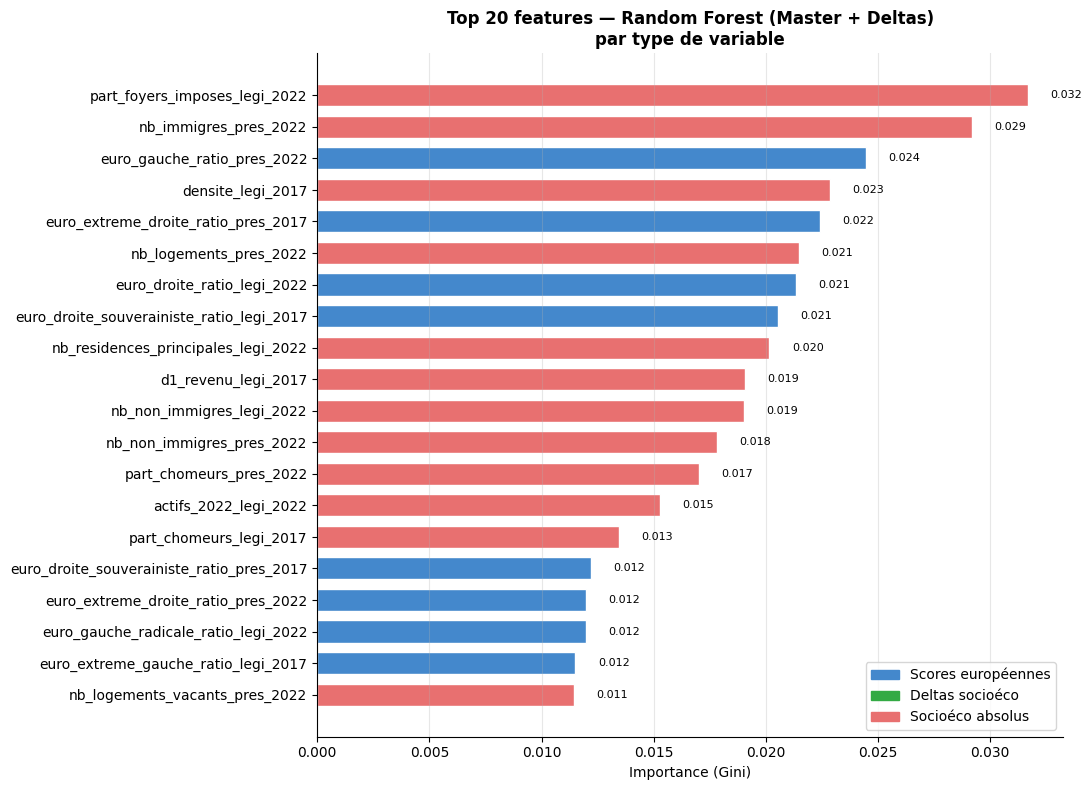

In [22]:
rf_pipeline = modeles_combined["Random Forest"]
rf_clf      = rf_pipeline.named_steps["clf"]

feature_names = X_combined.columns.tolist()
importances   = rf_clf.feature_importances_
indices       = np.argsort(importances)[::-1][:20]

top_features = [feature_names[i] for i in indices]
top_values   = [importances[i] for i in indices]

colors_imp = []
for f in top_features:
    if "euro_" in f:
        colors_imp.append("#4488CC")
    elif any(s in f for s in ["delta_", "pct_delta"]):
        colors_imp.append("#33AA44")
    else:
        colors_imp.append("#E87070")

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top_features[::-1], top_values[::-1],
               color=colors_imp[::-1], edgecolor="white", height=0.7)
ax.set_xlabel("Importance (Gini)")
ax.set_title("Top 20 features — Random Forest (Master + Deltas)\npar type de variable",
             fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)

legend_patches = [
    mpatches.Patch(color="#4488CC", label="Scores européennes"),
    mpatches.Patch(color="#33AA44", label="Deltas socioéco"),
    mpatches.Patch(color="#E87070", label="Socioéco absolus"),
]
ax.legend(handles=legend_patches, fontsize=10, loc="lower right")

for bar, val in zip(bars, top_values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC VIZ 6 — Radar chart comparaison 3 versions

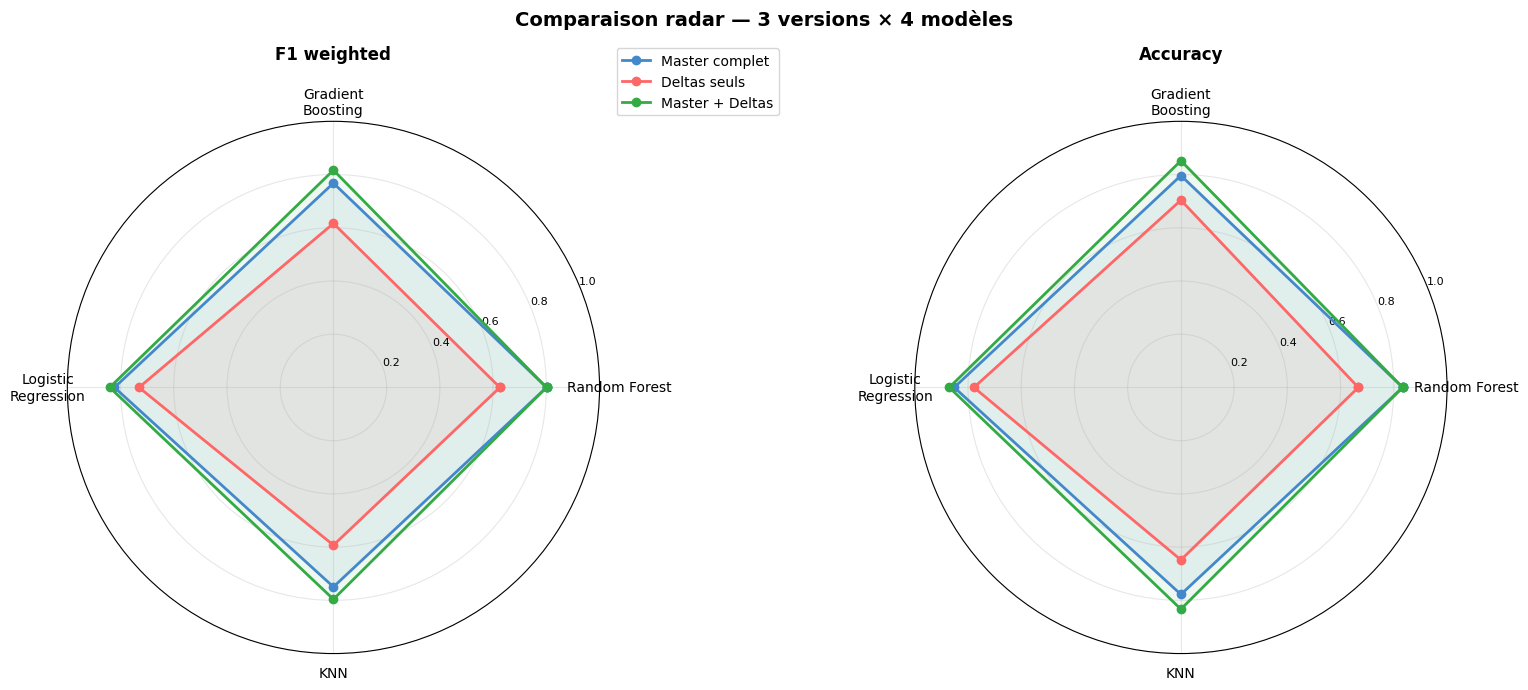

In [23]:
from matplotlib.patches import FancyArrowPatch

categories  = ["Random Forest", "Gradient\nBoosting", "Logistic\nRegression", "KNN"]
n_cat       = len(categories)
angles      = np.linspace(0, 2 * np.pi, n_cat, endpoint=False).tolist()
angles     += angles[:1]

versions_radar = [
    ("Master complet",  df_bilan,         "#4488CC"),
    ("Deltas seuls",    df_bilan_deltas,   "#FF6666"),
    ("Master + Deltas", df_bilan_combined, "#33AA44"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          subplot_kw=dict(polar=True))

for ax, metric, label_metric in zip(axes, ["f1_weighted", "accuracy"], ["F1 weighted", "Accuracy"]):
    for titre, df_v, color in versions_radar:
        df_v_sorted = df_v.set_index("modele").reindex(
            ["Random Forest", "Gradient Boosting", "Logistic Regression", "KNN"]
        )
        values  = df_v_sorted[metric].fillna(0).tolist()
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=2, color=color, label=titre)
        ax.fill(angles, values, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
    ax.set_title(label_metric, fontsize=12, fontweight="bold", pad=20)
    ax.grid(alpha=0.3)
    if metric == "f1_weighted":
        ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.suptitle("Comparaison radar — 3 versions × 4 modèles",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_radar_comparaison.png", bbox_inches="tight", dpi=150)
plt.show()

BLOC VIZ 7 — Tableau de bord final récapitulatif

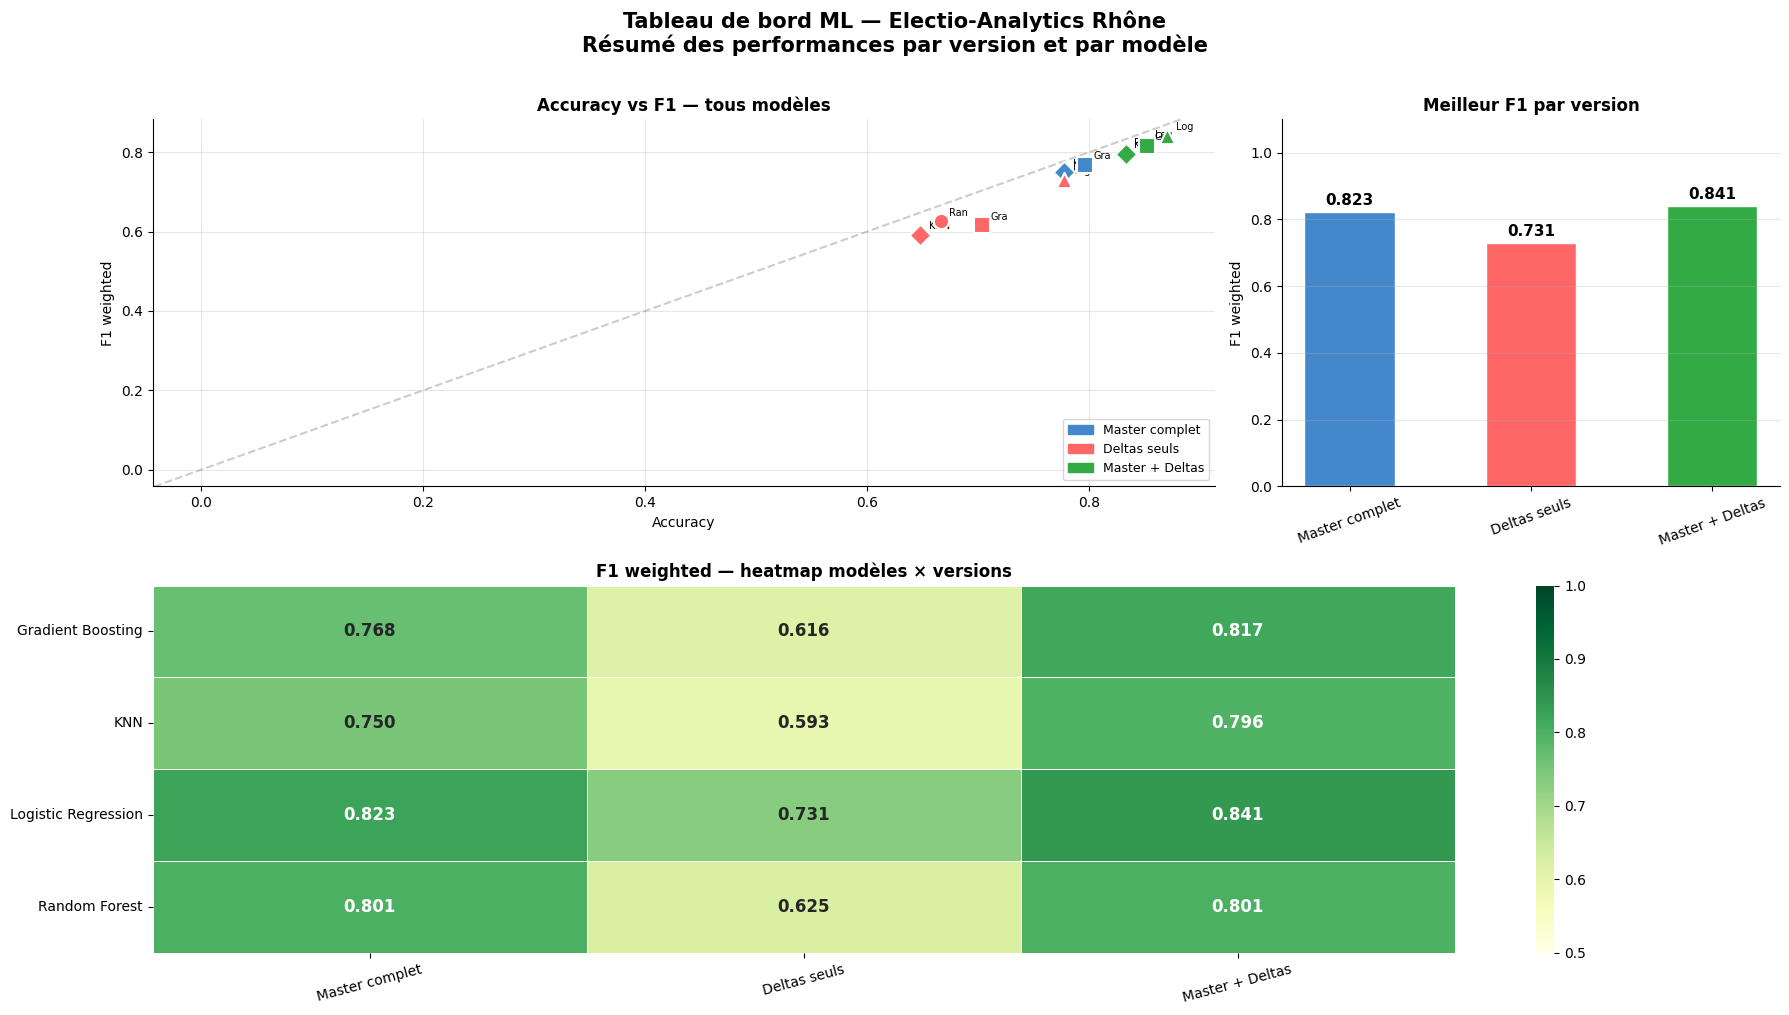

In [24]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Tableau de bord ML — Electio-Analytics Rhône\nRésumé des performances par version et par modèle",
             fontsize=15, fontweight="bold", y=1.01)

df_all = pd.concat([
    df_bilan.assign(version="Master complet"),
    df_bilan_deltas.assign(version="Deltas seuls"),
    df_bilan_combined.assign(version="Master + Deltas"),
], ignore_index=True)

couleurs_versions = {
    "Master complet" : "#4488CC",
    "Deltas seuls"   : "#FF6666",
    "Master + Deltas": "#33AA44",
}
markers_modeles = {
    "Random Forest"      : "o",
    "Gradient Boosting"  : "s",
    "Logistic Regression": "^",
    "KNN"                : "D",
}

# Panel 1 — Scatter accuracy vs F1
ax1 = fig.add_subplot(2, 3, (1, 2))
for _, row in df_all.iterrows():
    ax1.scatter(row["accuracy"], row["f1_weighted"],
                color=couleurs_versions[row["version"]],
                marker=markers_modeles.get(row["modele"], "o"),
                s=120, zorder=5, edgecolors="white", linewidth=1.5)
    ax1.annotate(f"{row['modele'][:3]}",
                 (row["accuracy"], row["f1_weighted"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7)
ax1.axline((0, 0), slope=1, color="gray", linestyle="--", alpha=0.4, label="Accuracy = F1")
ax1.set_xlabel("Accuracy")
ax1.set_ylabel("F1 weighted")
ax1.set_title("Accuracy vs F1 — tous modèles", fontweight="bold")
ax1.grid(alpha=0.3)
ax1.spines[["top", "right"]].set_visible(False)
legend_v = [mpatches.Patch(color=c, label=v) for v, c in couleurs_versions.items()]
ax1.legend(handles=legend_v, fontsize=9, loc="lower right")

# Panel 2 — Meilleur F1 par version
ax2 = fig.add_subplot(2, 3, 3)
best_by_version = df_all.groupby("version")["f1_weighted"].max().reindex(
    ["Master complet", "Deltas seuls", "Master + Deltas"]
)
bars = ax2.bar(best_by_version.index,
               best_by_version.values,
               color=[couleurs_versions[v] for v in best_by_version.index],
               edgecolor="white", width=0.5)
ax2.set_ylim(0, 1.1)
ax2.set_title("Meilleur F1 par version", fontweight="bold")
ax2.set_ylabel("F1 weighted")
ax2.tick_params(axis="x", rotation=20)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, best_by_version.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

# Panel 3 — Heatmap performances
ax3 = fig.add_subplot(2, 3, (4, 6))
pivot_perf = df_all.pivot_table(index="modele", columns="version",
                                 values="f1_weighted", aggfunc="mean")
pivot_perf = pivot_perf[["Master complet", "Deltas seuls", "Master + Deltas"]]
sns.heatmap(pivot_perf, annot=True, fmt=".3f", cmap="YlGn",
            vmin=0.5, vmax=1.0, linewidths=0.5, linecolor="white",
            ax=ax3, annot_kws={"size": 12, "weight": "bold"})
ax3.set_title("F1 weighted — heatmap modèles × versions", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.tick_params(axis="x", rotation=15)
ax3.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_dashboard_final.png", bbox_inches="tight", dpi=150)
plt.show()